# Convergence with $n_\mathrm{train}$ and $b_x$ (coverage)

Noisy **coverage** LH test set ($n=1000$ mocks per grid point; `submit_inf_test.sh` coverage preset). Metrics are row-averaged over available coverage mocks (incomplete runs included).

**MSE / MAFE:** per physical parameter ($\Omega_m$, $\sigma_8$, $b_1$).

**FoM:** $1/\sqrt{\det C}$ (full posterior covariance); marginal $1/\sigma_i$ and $1/\sqrt{\det C_3}$ on the 3-key block ($\Omega_\mathrm{c}$, $\sigma_8$, $\sigma_8 b_1$).

**FoB** (from [2026-05-01 kmax notebook](2026-05-01_kmax_scale_cuts.ipynb)): marginal unsigned FoB $= |\hat\theta-\theta_\mathrm{true}|/\sigma$; **FoB$_{3D}$** $= \sqrt{\chi^2}$ over the $3\times3$ block. Reference: $\sqrt{\chi^2_P(68\%)}$.


In [1]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import pandas as pd
from matplotlib import colors as mcolors
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.stats import chi2

import paths
import data_loader
import utils_plot
import utils_inference as ui

%load_ext autoreload
%autoreload 2

In [2]:
# --- Config (matches submit_inf_train.sh / noisy fixed-cosmo tests) ---
data_mode = "muchisimocks"
statistics = ["pk", "bispec", "pgm"]
tag_masks = "_kb0.25_kpgm0.25"
tag_params = "_p5_n10000"
tag_biasparams = "_biasnoisenest_p9_n320000"
tag_noise = "_noise_unit_p5_n10000"
tag_reparam = "_rp"
TAG_INF_BEST_SUFFIX = "_best-rand30"

TAG_PARAMS_TEST = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST = "_mean"

# Noisy coverage test set (1000 LH mocks; matches submit_inf_test.sh coverage preset)
TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"
N_COVERAGE = 1000

n_train_arr = [500, 1000, 2000, 4000, 6000, 8000, 10000]
bx_arr = [1, 2, 4, 8, 16, 32]
BX_MAX = max(bx_arr)
N_TRAIN_MAX = max(n_train_arr)

# User-facing names -> inference / physical param names after unreparameterization
PARAMS_TRACK = {
    "omega_m": "omega_cold",
    "sigma8": "sigma8_cold",
    "b1": "b1",
}
PARAM_LABELS = {
    "omega_m": r"$\Omega_m$",
    "sigma8": r"$\sigma_8$",
    "b1": r"$b_1$",
}
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]

PARAM_COLORS = {
    "omega_m": COLORS_FID[0],
    "sigma8": COLORS_FID[1],
    "b1": COLORS_FID[2],
}

# FoB uses reparameterized coords (same as 2026-05-01_kmax_scale_cuts.ipynb)
PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
FOB_KEYS = ["omega_m", "sigma8", "sigma8_b1"]
FOB_LABELS = {
    "omega_m": r"$\Omega_\mathrm{c}$",
    "sigma8": r"$\sigma_8$",
    "sigma8_b1": r"$\sigma_8 b_1$",
}
FOB_COLORS = {
    "omega_m": COLORS_FID[0],
    "sigma8": COLORS_FID[1],
    "sigma8_b1": COLORS_FID[2],
}
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8
SEQ_CMAP = "plasma_r"  # sequential colors for $b_x$ / $n_\mathrm{train}$ curves (matches paper figures)
SEQ_CMAP_LO, SEQ_CMAP_HI = 0.25, 0.95

In [3]:
def build_tag_inf(
    bx: int,
    n_train: int,
    *,
    statistics=None,
    tag_masks=None,
) -> str:
    statistics = statistics if statistics is not None else globals()["statistics"]
    tag_masks = tag_masks if tag_masks is not None else globals()["tag_masks"]
    tag_stats = f"_{'_'.join(statistics)}"
    base = (
        f"_{data_mode}{tag_stats}{tag_masks}{tag_params}{tag_biasparams}"
        f"{tag_noise}{tag_reparam}_bx{bx}_ntrain{n_train}"
    )
    return base + TAG_INF_BEST_SUFFIX


def build_tag_test(*, statistics=None, tag_masks=None) -> str:
    statistics = statistics if statistics is not None else globals()["statistics"]
    tag_masks = tag_masks if tag_masks is not None else globals()["tag_masks"]
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}{TAG_PARAMS_TEST}"
        f"{TAG_BIASPARAMS_TEST}{TAG_NOISE_TEST}{TAG_DATAGEN_TEST}"
    )


def build_tag_test_coverage(*, statistics=None, tag_masks=None) -> str:
    statistics = statistics if statistics is not None else globals()["statistics"]
    tag_masks = tag_masks if tag_masks is not None else globals()["tag_masks"]
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}{TAG_PARAMS_TEST_COV}"
        f"{TAG_BIASPARAMS_TEST_COV}{TAG_NOISE_TEST_COV}"
    )


def fob_chi2_sqrt_limit(ndims: int) -> float:
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


def compute_fob(theta_pred_row, cov, param_names, theta_true, param_vary):
    names = list(param_names)
    theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
    names_rep = list(names_rep)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    mu = np.array(
        [float(theta_pred_row[names.index(pn)]) for pn in PARAM_NAMES_FOB], dtype=float,
    )
    true_fob = np.array(
        [theta_true_rep[names_rep.index(pn)] for pn in PARAM_NAMES_FOB], dtype=float,
    )
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, _ = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def compute_fom_key_block(cov, param_names):
    names = list(param_names)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)]
    fom_marg = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[key] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


def load_metrics(
    bx: int,
    n_train: int,
    tag_test=None,
    *,
    statistics=None,
    tag_masks=None,
):
    statistics = statistics if statistics is not None else globals()["statistics"]
    tag_masks = tag_masks if tag_masks is not None else globals()["tag_masks"]
    if tag_test is None:
        tag_test = build_tag_test(statistics=statistics, tag_masks=tag_masks)
    tag_inf = build_tag_inf(bx, n_train, statistics=statistics, tag_masks=tag_masks)
    fn = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"
    if not fn.is_file():
        return None
    theta_pred, covs_pred, param_names = ui.get_moments_test_sbi(tag_inf, tag_test=tag_test)
    if theta_pred.size == 0:
        return None
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        tag_params, tag_biasparams, bx=bx,
    )
    theta_true = data_loader.load_theta_test(
        TAG_PARAMS_TEST, TAG_BIASPARAMS_TEST,
        cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
    )
    if theta_pred.ndim == 2:
        theta_pred_row = theta_pred[0]
        cov = covs_pred[0] if covs_pred.ndim == 3 else covs_pred
    else:
        theta_pred_row = theta_pred
        cov = covs_pred

    theta_pred_phys, names_phys = ui.unreparameterize_theta(theta_pred_row, param_names)
    theta_true_phys, _ = ui.unreparameterize_theta(theta_true, param_names)
    names_phys = list(names_phys)

    metrics = {"bx": bx, "n_train": n_train, "n_sims": bx * n_train}
    mse = {}
    mafe = {}
    for key, pname in PARAMS_TRACK.items():
        idx = names_phys.index(pname)
        true_val = float(theta_true_phys[idx])
        pred_val = float(theta_pred_phys[idx])
        err = pred_val - true_val
        mse[key] = err ** 2
        mafe[key] = abs(err / true_val) if true_val != 0 else np.nan
        metrics[f"true_{key}"] = true_val
        metrics[f"pred_{key}"] = pred_val
    metrics["mse"] = mse
    metrics["mafe"] = mafe
    metrics["fom"] = float(ui.figure_of_merit(cov))
    fom_marg, fom_3d = compute_fom_key_block(cov, param_names)
    metrics["fom_marg"] = fom_marg
    metrics["fom_3d"] = fom_3d
    fob, fob3 = compute_fob(theta_pred_row, cov, param_names, theta_true, param_vary)
    metrics["fob"] = fob
    metrics["fob3"] = fob3
    for key in PARAMS_TRACK:
        metrics[f"mse_{key}"] = mse[key]
        metrics[f"mafe_{key}"] = mafe[key]
    return metrics


def _grid_columns():
    cols = ["bx", "n_train", "n_sims", "fom", "fom_3d", "fob3"]
    for key in PARAMS_TRACK:
        cols.extend([f"mse_{key}", f"mafe_{key}", f"true_{key}", f"pred_{key}"])
    for key in FOB_KEYS:
        cols.extend([f"fom_{key}", f"fob_{key}"])
    return cols


def empty_grid_df():
    return pd.DataFrame(columns=_grid_columns())


def collect_grid(
    n_train_values,
    bx_values,
    tag_test=None,
    *,
    statistics=None,
    tag_masks=None,
):
    if tag_test is None:
        tag_test = build_tag_test(statistics=statistics, tag_masks=tag_masks)
    rows = []
    for bx in bx_values:
        for n_train in n_train_values:
            m = load_metrics(
                bx, n_train, tag_test,
                statistics=statistics, tag_masks=tag_masks,
            )
            if m is None:
                print(f"Missing: bx={bx}, n_train={n_train}")
                continue
            row = {
                "bx": bx,
                "n_train": n_train,
                "n_sims": bx * n_train,
                "fom": m["fom"],
                "fom_3d": m["fom_3d"],
                "fob3": m["fob3"],
            }
            for key in PARAMS_TRACK:
                row[f"mse_{key}"] = m["mse"][key]
                row[f"mafe_{key}"] = m["mafe"][key]
                row[f"true_{key}"] = m[f"true_{key}"]
                row[f"pred_{key}"] = m[f"pred_{key}"]
            for key in FOB_KEYS:
                row[f"fom_{key}"] = m["fom_marg"][key]
                row[f"fob_{key}"] = m["fob"][key]
            rows.append(row)
    return pd.DataFrame(rows) if rows else empty_grid_df()


def _apply_logx(ax, logx: bool):
    if logx:
        ax.set_xscale("log")


def _plot_param_panels(df, x_col, xlabel, title_prefix, *, value_prefix, ylabel, logx=False, logy=True):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix}")
        return
    df = df.sort_values(x_col)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, PARAMS_TRACK):
        ax.plot(df[x_col], df[f"{value_prefix}_{key}"], color=PARAM_COLORS[key])
        ax.set_title(PARAM_LABELS[key])
        ax.set_ylabel(ylabel)
        _apply_logx(ax, logx)
        if logy:
            ax.set_yscale("log")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(f"{title_prefix}: {value_prefix}", y=1.06)
    fig.tight_layout()
    plt.show()


def plot_mse(df, x_col, xlabel, title_prefix, *, logx=False, logy=True):
    _plot_param_panels(
        df, x_col, xlabel, title_prefix,
        value_prefix="mse", ylabel="MSE", logx=logx, logy=logy,
    )


def plot_mafe(df, x_col, xlabel, title_prefix, *, logx=False, logy=True):
    _plot_param_panels(
        df, x_col, xlabel, title_prefix,
        value_prefix="mafe", ylabel="|fractional error|", logx=logx, logy=logy,
    )


def plot_fom(df, x_col, xlabel, title_prefix, *, logx=False, logy=True):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoM)")
        return
    df = df.sort_values(x_col)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df[x_col], df["fom"], color="k")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("FoM")
    ax.set_title(f"{title_prefix}: figure of merit")
    _apply_logx(ax, logx)
    if logy:
        ax.set_yscale("log")
    fig.tight_layout()
    plt.show()


def plot_fob(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB)")
        return
    df = df.sort_values(x_col)
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        ax.plot(df[x_col], df[f"fob_{key}"], color=FOB_COLORS[key])
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7, label=r"$\sqrt{2/\pi}$")
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{1}}(68\%)}}$")
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoB")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(f"{title_prefix}: FoB $= |\\hat{{\\theta}}-\\theta_{{\\mathrm{{true}}}}|/\\sigma$", y=1.06)
    fig.tight_layout()
    plt.show()


def plot_fob3(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB3D)")
        return
    df = df.sort_values(x_col)
    lim3 = fob_chi2_sqrt_limit(3)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df[x_col], df["fob3"], color="k")
    ax.axhline(lim3, color="gray", ls=":", lw=1, alpha=0.7,
               label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"FoB$_{\mathrm{3D}}$")
    ax.set_title(f"{title_prefix}: FoB$_{{3D}}$ ($P=3$)")
    ax.legend(fontsize=8)
    _apply_logx(ax, logx)
    fig.tight_layout()
    plt.show()


def _sequential_color_map(values, *, cmap_name=SEQ_CMAP, lo=SEQ_CMAP_LO, hi=SEQ_CMAP_HI):
    values_sorted = sorted(values)
    cmap = plt.get_cmap(cmap_name)
    if len(values_sorted) == 1:
        return {values_sorted[0]: cmap(0.5 * (lo + hi))}
    samples = np.linspace(lo, hi, len(values_sorted))
    return {v: cmap(t) for v, t in zip(values_sorted, samples)}


def bx_colors(bx_values, **kwargs):
    return _sequential_color_map(bx_values, **kwargs)


def n_train_colors(n_train_values, **kwargs):
    return _sequential_color_map(n_train_values, **kwargs)


def plot_metric_colored_by_bx(df, x_col, y_col, xlabel, ylabel, title, *, logx=False, logy=False, cmap_name=SEQ_CMAP):
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        print(f"No data for {title}")
        return
    color_map = bx_colors(df["bx"].unique(), cmap_name=cmap_name)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for bx in sorted(df["bx"].unique()):
        sub = df[df["bx"] == bx].sort_values(x_col)
        ax.plot(sub[x_col], sub[y_col], ls="-", color=color_map[bx], label=rf"$b_x={bx}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    _apply_logx(ax, logx)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2, title=rf"$b_x$")
    fig.tight_layout()
    plt.show()


def plot_fob_colored_by_bx(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB by $b_x$)")
        return
    color_map = bx_colors(df["bx"].unique())
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        for bx in sorted(df["bx"].unique()):
            sub = df[df["bx"] == bx].sort_values(x_col)
            ax.plot(sub[x_col], sub[f"fob_{key}"], ls="-", color=color_map[bx], label=rf"$b_x={bx}$")
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7, label=r"$\sqrt{2/\pi}$")
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{1}}(68\%)}}$")
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoB")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best", ncol=2, title=rf"$b_x$")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(
        f"{title_prefix}: FoB $= |\\hat{{\\theta}}-\\theta_{{\\mathrm{{true}}}}|/\\sigma$ (colored by $b_x$)",
        y=1.08,
    )
    fig.tight_layout()
    plt.show()


def plot_fob3_colored_by_bx(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB3D by $b_x$)")
        return
    color_map = bx_colors(df["bx"].unique())
    lim3 = fob_chi2_sqrt_limit(3)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for bx in sorted(df["bx"].unique()):
        sub = df[df["bx"] == bx].sort_values(x_col)
        ax.plot(sub[x_col], sub["fob3"], ls="-", color=color_map[bx], label=rf"$b_x={bx}$")
    ax.axhline(lim3, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"FoB$_{\mathrm{3D}}$")
    ax.set_title(f"{title_prefix}: FoB$_{{3D}}$ ($P=3$, colored by $b_x$)")
    ax.legend(fontsize=8, ncol=2, title=rf"$b_x$")
    _apply_logx(ax, logx)
    fig.tight_layout()
    plt.show()


def plot_total_sims_colored_by_bx(df, title_prefix):
    xlabel = r"$n_\mathrm{train} \times b_x$"
    plot_metric_colored_by_bx(
        df, "n_sims", "fom", xlabel, "FoM",
        f"{title_prefix}: FoM vs total training sims (colored by $b_x$)",
        logx=True, logy=True,
    )
    plot_fob_colored_by_bx(df, "n_sims", xlabel, title_prefix, logx=True)
    plot_fob3_colored_by_bx(df, "n_sims", xlabel, title_prefix, logx=True)


def plot_metric_colored_by_ntrain(df, x_col, y_col, xlabel, ylabel, title, *, logx=False, logy=False, cmap_name=SEQ_CMAP):
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        print(f"No data for {title}")
        return
    color_map = n_train_colors(df["n_train"].unique(), cmap_name=cmap_name)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for n_train in sorted(df["n_train"].unique()):
        sub = df[df["n_train"] == n_train].sort_values(x_col)
        ax.plot(sub[x_col], sub[y_col], ls="-", color=color_map[n_train], label=rf"$n_\mathrm{{train}}={n_train}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    _apply_logx(ax, logx)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2, title=rf"$n_\mathrm{{train}}$")
    fig.tight_layout()
    plt.show()


def plot_fob_colored_by_ntrain(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB by $n_\mathrm{{train}}$)")
        return
    color_map = n_train_colors(df["n_train"].unique())
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        for n_train in sorted(df["n_train"].unique()):
            sub = df[df["n_train"] == n_train].sort_values(x_col)
            ax.plot(sub[x_col], sub[f"fob_{key}"], ls="-", color=color_map[n_train], label=rf"$n_\mathrm{{train}}={n_train}$")
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7, label=r"$\sqrt{2/\pi}$")
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{1}}(68\%)}}$")
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoB")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best", ncol=2, title=rf"$n_\mathrm{{train}}$")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(
        f"{title_prefix}: FoB $= |\\hat{{\\theta}}-\\theta_{{\\mathrm{{true}}}}|/\\sigma$ (colored by $n_\mathrm{{train}}$)",
        y=1.08,
    )
    fig.tight_layout()
    plt.show()


def plot_fob3_colored_by_ntrain(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (FoB3D by $n_\mathrm{{train}}$)")
        return
    color_map = n_train_colors(df["n_train"].unique())
    lim3 = fob_chi2_sqrt_limit(3)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for n_train in sorted(df["n_train"].unique()):
        sub = df[df["n_train"] == n_train].sort_values(x_col)
        ax.plot(sub[x_col], sub["fob3"], ls="-", color=color_map[n_train], label=rf"$n_\mathrm{{train}}={n_train}$")
    ax.axhline(lim3, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"FoB$_{\mathrm{3D}}$")
    ax.set_title(f"{title_prefix}: FoB$_{{3D}}$ ($P=3$, colored by $n_\mathrm{{train}}$)")
    ax.legend(fontsize=8, ncol=2, title=rf"$n_\mathrm{{train}}$")
    _apply_logx(ax, logx)
    fig.tight_layout()
    plt.show()


def plot_total_sims_colored_by_ntrain(df, title_prefix):
    xlabel = r"$n_\mathrm{train} \times b_x$"
    plot_metric_colored_by_ntrain(
        df, "n_sims", "fom", xlabel, "FoM",
        f"{title_prefix}: FoM vs total training sims (colored by $n_\mathrm{{train}}$)",
        logx=True, logy=True,
    )
    plot_fob_colored_by_ntrain(df, "n_sims", xlabel, title_prefix, logx=True)
    plot_fob3_colored_by_ntrain(df, "n_sims", xlabel, title_prefix, logx=True)


def plot_all_metrics(df, x_col, xlabel, title_prefix, *, logx=False):
    plot_mse(df, x_col, xlabel, title_prefix, logx=logx)
    plot_mafe(df, x_col, xlabel, title_prefix, logx=logx)
    plot_fob(df, x_col, xlabel, title_prefix, logx=logx)
    plot_fob3(df, x_col, xlabel, title_prefix, logx=logx)
    plot_fom(df, x_col, xlabel, title_prefix, logx=logx)


def _coverage_samples_path(tag_inf: str, tag_test: str):
    base = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
    fn = base / f"samples_test{tag_test}_pred.npy"
    if fn.is_file():
        return fn, False
    fn_ip = base / f"samples_test{tag_test}_pred_inprogress.npy"
    if fn_ip.is_file():
        return fn_ip, True
    return None, False


def _finite_sample_rows(samples_arr):
    """Indices of coverage rows with finite posterior chains (failed batches are all-NaN)."""
    if samples_arr.ndim != 3:
        raise ValueError(f"expected 3D samples, got {samples_arr.shape}")
    theta_pred = np.nanmean(samples_arr, axis=0)
    return np.where(np.all(np.isfinite(theta_pred), axis=1))[0]


def _moments_from_samples_3d(samples_arr: np.ndarray, param_names):
    rows = _finite_sample_rows(samples_arr)
    npar = samples_arr.shape[2]
    if rows.size == 0:
        return np.empty((0, npar)), np.empty((0, npar, npar)), list(param_names), rows
    theta_pred = np.array([np.nanmean(samples_arr[:, i, :], axis=0) for i in rows])
    covs_pred = np.array([np.cov(samples_arr[:, i, :].T) for i in rows])
    return theta_pred, covs_pred, list(param_names), rows


def load_coverage_metrics(bx, n_train, tag_test=None, *, statistics=None, tag_masks=None):
    statistics = statistics if statistics is not None else globals()["statistics"]
    tag_masks = tag_masks if tag_masks is not None else globals()["tag_masks"]
    if tag_test is None:
        tag_test = build_tag_test_coverage(statistics=statistics, tag_masks=tag_masks)
    tag_inf = build_tag_inf(bx, n_train, statistics=statistics, tag_masks=tag_masks)
    fn, _ = _coverage_samples_path(tag_inf, tag_test)
    if fn is None:
        return None, "missing"
    samples_arr = np.load(fn)
    fn_pn = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}" / "param_names.txt"
    if not fn_pn.is_file():
        return None, "missing"
    param_names_all = np.loadtxt(fn_pn, dtype=str)
    if samples_arr.ndim != 3:
        return None, "bad_shape"
    n_obs_file = int(samples_arr.shape[1])
    if n_obs_file == 0:
        return None, "missing"
    theta_pred, covs_pred, param_names, rows = _moments_from_samples_3d(samples_arr, param_names_all)
    if rows.size == 0:
        return None, "missing"
    n_cov = int(rows.size)
    status = "complete" if n_cov == N_COVERAGE else "incomplete"
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(tag_params, tag_biasparams, bx=bx)
    theta_true_all = data_loader.load_theta_test(
        TAG_PARAMS_TEST_COV, TAG_BIASPARAMS_TEST_COV,
        cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
    )
    if theta_true_all.ndim == 1:
        theta_true_all = np.tile(theta_true_all, (n_obs_file, 1))
    theta_true_all = theta_true_all[rows]
    n_use = theta_pred.shape[0]
    mse_lists = {key: [] for key in PARAMS_TRACK}
    mafe_lists = {key: [] for key in PARAMS_TRACK}
    fob_lists = {key: [] for key in FOB_KEYS}
    fom_marg_lists = {key: [] for key in FOB_KEYS}
    fob3_list = []
    fom_list = []
    fom_3d_list = []
    for i in range(n_use):
        cov_i = covs_pred[i]
        fom_list.append(float(ui.figure_of_merit(cov_i)))
        fom_marg, fom_3d = compute_fom_key_block(cov_i, param_names)
        fom_3d_list.append(fom_3d)
        for key in FOB_KEYS:
            fom_marg_lists[key].append(fom_marg[key])
        fob, fob3 = compute_fob(theta_pred[i], cov_i, param_names, theta_true_all[i], param_vary)
        for key in FOB_KEYS:
            fob_lists[key].append(fob[key])
        fob3_list.append(fob3)

        theta_pred_phys, names_phys = ui.unreparameterize_theta(theta_pred[i], param_names)
        names_phys = list(names_phys)
        theta_true_phys = {
            pn: float(theta_true_all[i, list(param_vary).index(pn)])
            for pn in param_vary
        }
        for key, pname in PARAMS_TRACK.items():
            true_val = theta_true_phys[pname]
            pred_val = float(theta_pred_phys[names_phys.index(pname)])
            err = pred_val - true_val
            mse_lists[key].append(err ** 2)
            mafe_lists[key].append(abs(err / true_val) if true_val != 0 else np.nan)
    metrics = {
        "n_cov": n_cov,
        "fom": float(np.nanmean(fom_list)),
        "fom_3d": float(np.nanmean(fom_3d_list)),
        "fob3": float(np.nanmean(fob3_list)),
        "mse": {key: float(np.nanmean(mse_lists[key])) for key in PARAMS_TRACK},
        "mafe": {key: float(np.nanmean(mafe_lists[key])) for key in PARAMS_TRACK},
        "fom_marg": {key: float(np.nanmean(fom_marg_lists[key])) for key in FOB_KEYS},
        "fob": {key: float(np.nanmean(fob_lists[key])) for key in FOB_KEYS},
    }
    return metrics, status


def collect_coverage_grid(n_train_values, bx_values, tag_test=None, *, statistics=None, tag_masks=None):
    if tag_test is None:
        tag_test = build_tag_test_coverage(statistics=statistics, tag_masks=tag_masks)
    rows = []
    missing = []
    incomplete = []
    for bx in bx_values:
        for n_train in n_train_values:
            m, status = load_coverage_metrics(bx, n_train, tag_test, statistics=statistics, tag_masks=tag_masks)
            if m is None:
                missing.append((bx, n_train, status))
                print(f"Coverage missing ({status}): bx={bx}, n_train={n_train}")
                continue
            if status != "complete":
                incomplete.append((bx, n_train, m["n_cov"], status))
                print(f"Coverage incomplete ({status}): bx={bx}, n_train={n_train}, n_obs={m['n_cov']} / {N_COVERAGE}")
            row = {
                "bx": bx, "n_train": n_train, "n_sims": bx * n_train,
                "n_cov": m["n_cov"], "status": status,
                "fom": m["fom"], "fom_3d": m["fom_3d"], "fob3": m["fob3"],
            }
            for key in PARAMS_TRACK:
                row[f"mse_{key}"] = m["mse"][key]
                row[f"mafe_{key}"] = m["mafe"][key]
            for key in FOB_KEYS:
                row[f"fom_{key}"] = m["fom_marg"][key]
                row[f"fob_{key}"] = m["fob"][key]
            rows.append(row)
    n_expected = len(n_train_values) * len(bx_values)
    print(f"Coverage summary: {len(rows)} loaded, {(pd.DataFrame(rows)['status'] == 'complete').sum() if rows else 0} complete / {n_expected} grid points; {len(missing)} missing, {len(incomplete)} incomplete")
    return pd.DataFrame(rows) if rows else empty_grid_df()


STATISTICS_ARR_FID = [["pk"], ["pk", "pgm"], ["pk", "bispec"], ["pk", "bispec", "pgm"]]
TAG_MASKS_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]


def stat_combo_label(statistics, tag_masks):
    return utils_plot.get_stat_label(statistics) + (f", {tag_masks}" if tag_masks else "")


STAT_COMBO_LABELS = [stat_combo_label(s, m) for s, m in zip(STATISTICS_ARR_FID, TAG_MASKS_FID)]
STAT_COMBO_COLORS = dict(zip(STAT_COMBO_LABELS, COLORS_FID))


def collect_stat_combo_coverage_grids(n_train_values, bx_values, *, complete_only=False):
    frames = []
    for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAG_MASKS_FID):
        label = stat_combo_label(statistics, tag_masks)
        df = collect_coverage_grid(n_train_values, bx_values, statistics=statistics, tag_masks=tag_masks)
        if df.empty:
            print(f"{label}: no coverage data")
            continue
        n_loaded = len(df)
        n_complete = int((df["status"] == "complete").sum())
        print(f"{label}: loaded {n_loaded} grid points ({n_complete} complete, {n_loaded - n_complete} incomplete / {len(n_train_values) * len(bx_values)} expected)")
        if complete_only:
            df = df[df["status"] == "complete"].copy()
            if df.empty:
                print("  (skipping — no complete coverage rows)")
                continue
        df = df.copy()
        df["stat_combo"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else empty_grid_df()


def plot_fom_marg_by_stat_combo(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (marginal FoM)")
        return
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        col = f"fom_{key}"
        for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAG_MASKS_FID):
            label = stat_combo_label(statistics, tag_masks)
            sub = df[df["stat_combo"] == label].sort_values(x_col)
            if sub.empty or col not in sub.columns:
                continue
            color = STAT_COMBO_COLORS[label]
            ax.plot(sub[x_col], sub[col], ls="-", color=color, label=label)
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(f"{title_prefix}: marginal FoM $= 1/\\sigma$ (3-key block)", y=1.06)
    fig.tight_layout()
    plt.show()


def plot_fob_marg_by_stat_combo(df, x_col, xlabel, title_prefix, *, logx=False):
    if df.empty or x_col not in df.columns:
        print(f"No data for {title_prefix} (marginal FoB)")
        return
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        col = f"fob_{key}"
        for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAG_MASKS_FID):
            label = stat_combo_label(statistics, tag_masks)
            sub = df[df["stat_combo"] == label].sort_values(x_col)
            if sub.empty or col not in sub.columns:
                continue
            color = STAT_COMBO_COLORS[label]
            ax.plot(sub[x_col], sub[col], ls="-", color=color, label=label)
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7, label=r"$\sqrt{2/\pi}$")
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7, label=rf"$\sqrt{{\chi^2_{{1}}(68\%)}}$")
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoB")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best")
    axes[-1].set_xlabel(xlabel)
    fig.suptitle(
        f"{title_prefix}: FoB $= |\\hat{{\\theta}}-\\theta_{{\\mathrm{{true}}}}|/\\sigma$ (3-key block)",
        y=1.06,
    )
    fig.tight_layout()
    plt.show()


def plot_fom_3d_by_stat_combo(df, x_col, xlabel, title_prefix, *, logx=False):
    plot_metric_by_stat_combo(
        df, x_col, "fom_3d", xlabel, r"FoM$_{3}$",
        f"{title_prefix}: FoM$_{{3}}$ ($P=3$ key block)", logx=logx, logy=True,
    )


def plot_metric_by_stat_combo(df, x_col, y_col, xlabel, ylabel, title, *, logx=False, logy=False, hline=None, hline_label=None, linestyle="-"):
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        print(f"No data for {title}")
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAG_MASKS_FID):
        label = stat_combo_label(statistics, tag_masks)
        sub = df[df["stat_combo"] == label].sort_values(x_col)
        if sub.empty:
            continue
        color = STAT_COMBO_COLORS[label]
        ax.plot(sub[x_col], sub[y_col], ls=linestyle, color=color, label=label)
    if hline is not None:
        ax.axhline(hline, color="gray", ls=":", lw=1, alpha=0.7, label=hline_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    _apply_logx(ax, logx)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    plt.show()


NT_ALPHA_LO, NT_ALPHA_HI = 0.15, 1.0


def n_train_alpha(n_train, n_train_values=None, *, lo=NT_ALPHA_LO, hi=NT_ALPHA_HI):
    n_train_values = sorted(n_train_values if n_train_values is not None else n_train_arr)
    if len(n_train_values) == 1:
        return hi
    t = n_train_values.index(int(n_train)) / (len(n_train_values) - 1)
    return lo + t * (hi - lo)


def _stat_combo_nsims_alpha_on_ax(ax, df, y_col, *, n_train_values=None, legend=False):
    n_train_values = sorted(n_train_values if n_train_values is not None else n_train_arr)
    for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAG_MASKS_FID):
        label = stat_combo_label(statistics, tag_masks)
        sub = df[df["stat_combo"] == label]
        if sub.empty or y_col not in sub.columns:
            continue
        rgb = mcolors.to_rgb(STAT_COMBO_COLORS[label])
        if legend:
            ax.plot([], [], color=rgb, ls="-", lw=1.5, label=label)
        for n_train in sorted(sub["n_train"].unique()):
            grp = sub[sub["n_train"] == n_train].sort_values("n_sims")
            alpha = n_train_alpha(n_train, n_train_values)
            rgba = (*rgb, alpha)
            ax.plot(grp["n_sims"], grp[y_col], color=rgba, ls="-", lw=1.5, zorder=1)


def plot_fom_marg_by_stat_combo_nsims_alpha(df, title_prefix, *, logx=True, n_train_values=None):
    if df.empty or "n_sims" not in df.columns:
        print(f"No data for {title_prefix} (marginal FoM vs n_sims)")
        return
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        col = f"fom_{key}"
        _stat_combo_nsims_alpha_on_ax(ax, df, col, n_train_values=n_train_values, legend=(key == FOB_KEYS[0]))
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best", title="stat combo")
    axes[-1].set_xlabel(r"$n_\mathrm{train} \times b_x$")
    fig.suptitle(f"{title_prefix}: marginal FoM vs total training sims", y=1.06)
    axes[0].text(0.02, 0.02, r"opacity $\propto n_\mathrm{train}$", transform=axes[0].transAxes, fontsize=8, color="0.35", va="bottom")
    fig.tight_layout()
    plt.show()


def plot_fob_marg_by_stat_combo_nsims_alpha(df, title_prefix, *, logx=True, n_train_values=None):
    if df.empty or "n_sims" not in df.columns:
        print(f"No data for {title_prefix} (marginal FoB vs n_sims)")
        return
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
    for ax, key in zip(axes, FOB_KEYS):
        col = f"fob_{key}"
        _stat_combo_nsims_alpha_on_ax(ax, df, col, n_train_values=n_train_values, legend=(key == FOB_KEYS[0]))
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7)
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7)
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoB")
        _apply_logx(ax, logx)
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best", title="stat combo")
    axes[-1].set_xlabel(r"$n_\mathrm{train} \times b_x$")
    fig.suptitle(f"{title_prefix}: marginal FoB vs total training sims", y=1.06)
    axes[0].text(0.02, 0.02, r"opacity $\propto n_\mathrm{train}$", transform=axes[0].transAxes, fontsize=8, color="0.35", va="bottom")
    fig.tight_layout()
    plt.show()


def plot_metric_by_stat_combo_nsims_alpha(df, y_col, ylabel, title, *, logx=True, logy=False, hline=None, hline_label=None, n_train_values=None):
    if df.empty or "n_sims" not in df.columns or y_col not in df.columns:
        print(f"No data for {title}")
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    _stat_combo_nsims_alpha_on_ax(ax, df, y_col, n_train_values=n_train_values, legend=True)
    if hline is not None:
        ax.axhline(hline, color="gray", ls=":", lw=1, alpha=0.7, label=hline_label)
    ax.set_xlabel(r"$n_\mathrm{train} \times b_x$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    _apply_logx(ax, logx)
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=8, loc="best", title="stat combo")
    ax.text(0.02, 0.02, r"opacity $\propto n_\mathrm{train}$", transform=ax.transAxes, fontsize=8, color="0.35", va="bottom")
    fig.tight_layout()
    plt.show()


## Coverage test set

Noisy **coverage** LH ($n=1000$ mocks per grid point; `submit_inf_test.sh` coverage preset). Same metrics as the SHAMe-mean section above, but **row-averaged** over coverage mocks (MSE, MAFE, FoB, FoB$_\mathrm{3D}$, FoM). Prints any grid points with missing or incomplete coverage inference output.

In [4]:
tag_test_cov = build_tag_test_coverage()
print(f"tag_test_cov = {tag_test_cov}")

df_cov_all = collect_coverage_grid(n_train_arr, bx_arr, tag_test_cov)
print(f"Loaded {len(df_cov_all)} / {len(n_train_arr) * len(bx_arr)} coverage grid points")
df_cov_all

tag_test_cov = _muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=1, n_train=2000, n_obs=420 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=2, n_train=8000, n_obs=820 / 1000
Coverage incomplete (incomplete): bx=8, n_train=500, n_obs=400 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=8, n_train=2000, n_obs=820 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=32, n_train=500, n_obs=820 / 1000
Coverage summary: 42 loaded, 37 complete / 42 grid points; 0 missing, 5 incomplete
Loaded 42 / 42 coverage grid points


,bx,n_train,n_sims,n_cov,status,fom,fom_3d,fob3,mse_omega_m,mafe_omega_m,mse_sigma8,mafe_sigma8,mse_b1,mafe_b1,fom_omega_m,fob_omega_m,fom_sigma8,fob_sigma8,fom_sigma8_b1,fob_sigma8_b1
0,1,500,500,1000,complete,2.250374e+04,10149.658627,1.955631,0.000869,0.075408,0.004530,0.075959,0.113734,0.887231,45.399940,0.978165,18.532544,1.068749,6.704995,0.959374
1,1,1000,1000,1000,complete,2.113296e+04,7260.303185,1.831734,0.001740,0.117983,0.003445,0.064326,0.097374,0.997251,27.142529,0.970345,20.818074,0.983518,6.559633,0.873640
2,1,2000,2000,420,incomplete,1.390960e+05,20022.579109,1.868635,0.000886,0.077839,0.002590,0.053100,0.053872,1.129786,42.061546,0.940795,26.471627,0.995264,8.986985,0.958102
3,1,4000,4000,1000,complete,2.375045e+05,22813.672007,1.809032,0.000639,0.062056,0.002630,0.054874,0.051289,0.684220,51.139368,0.881514,24.632158,0.969501,9.858054,0.965699
4,1,6000,6000,1000,complete,1.536874e+06,52249.633580,1.791923,0.000535,0.055763,0.002090,0.043696,0.031908,0.488632,59.761668,0.911810,36.043404,0.947813,12.426241,0.908801
5,1,8000,8000,1000,complete,2.496292e+06,63130.569514,1.707620,0.000514,0.054107,0.001754,0.038976,0.021078,0.453300,60.487147,0.874828,40.566472,0.891616,14.165201,0.833741
6,1,10000,10000,1000,complete,2.899771e+06,61646.422203,1.758394,0.000473,0.052666,0.001818,0.040130,0.024193,0.480915,66.382563,0.925189,36.536587,0.884335,13.688458,0.849601
7,2,500,1000,1000,complete,4.045201e+04,12443.454507,1.916876,0.000875,0.075335,0.003717,0.067572,0.113490,1.015654,45.540799,0.982314,20.476211,1.032124,7.257446,0.973045
8,2,1000,2000,1000,complete,1.469593e+05,23284.607056,1.871277,0.000658,0.062067,0.003102,0.060304,0.061695,0.778773,52.890286,0.914879,22.277542,0.977705,9.145277,0.962383
9,2,2000,4000,1000,complete,2.780329e+05,28426.378022,1.839290,0.000822,0.072543,0.002177,0.046826,0.037532,0.598636,44.037594,0.908020,32.306301,1.001045,10.974949,0.936572


### Fix $b_x = 32$, vary $n_\mathrm{train}$ (coverage)

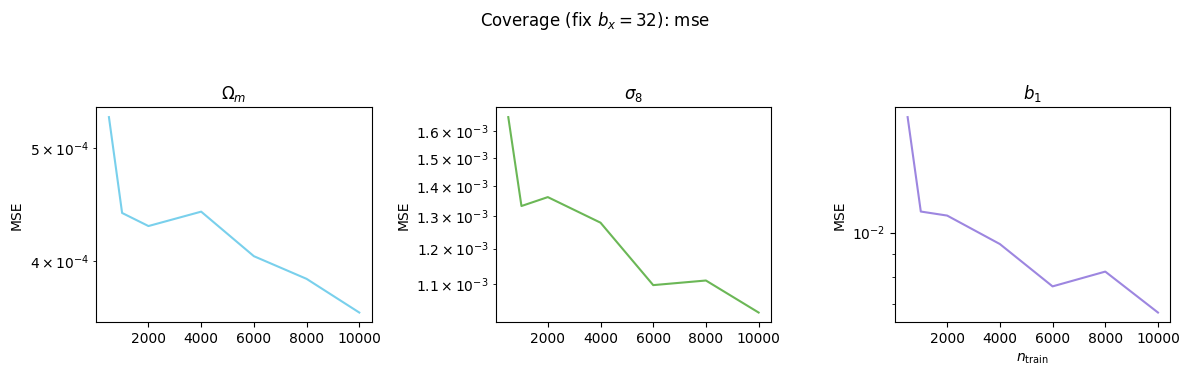

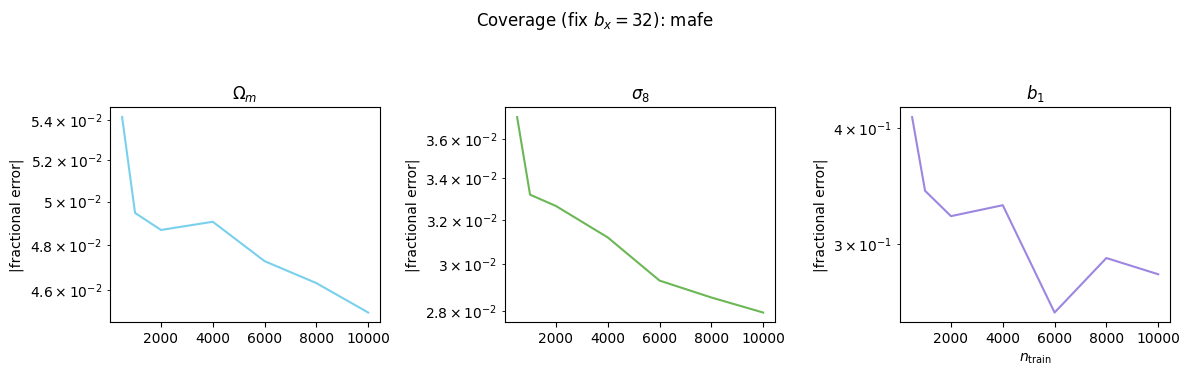

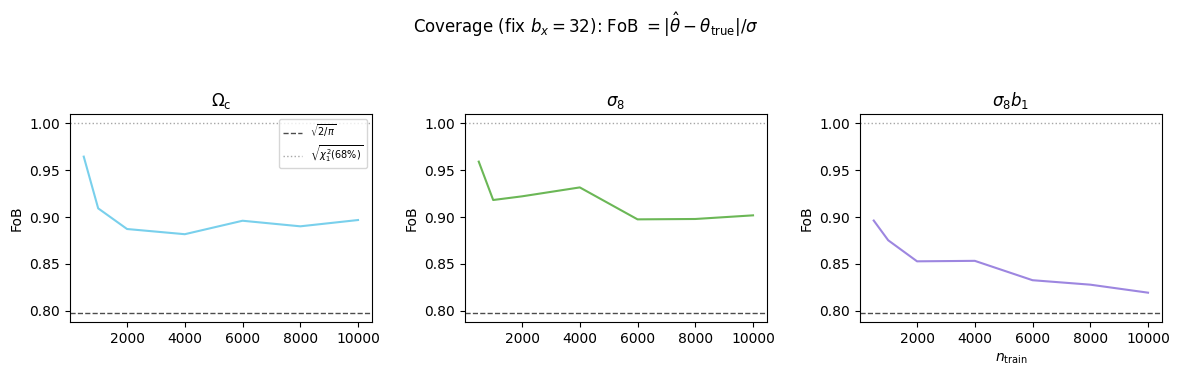

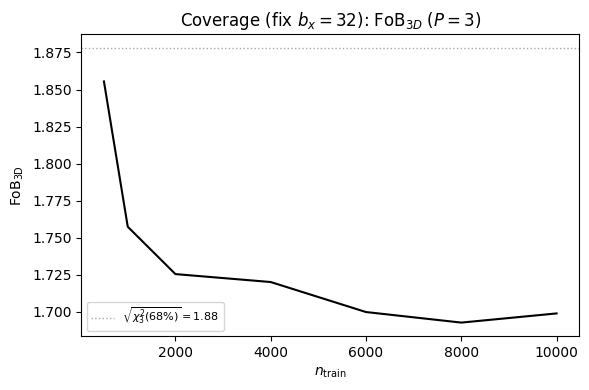

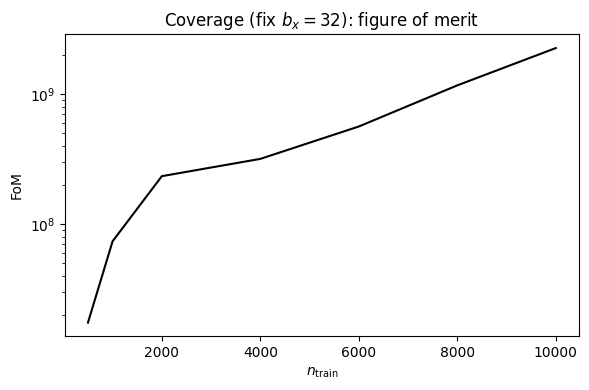

In [5]:
df_cov_vary_ntrain = df_cov_all[df_cov_all["bx"] == BX_MAX].copy()
plot_all_metrics(
    df_cov_vary_ntrain,
    "n_train",
    r"$n_\mathrm{train}$",
    rf"Coverage (fix $b_x={BX_MAX}$)",
)

### Fix $n_\mathrm{train} = 10000$, vary $b_x$ (coverage)

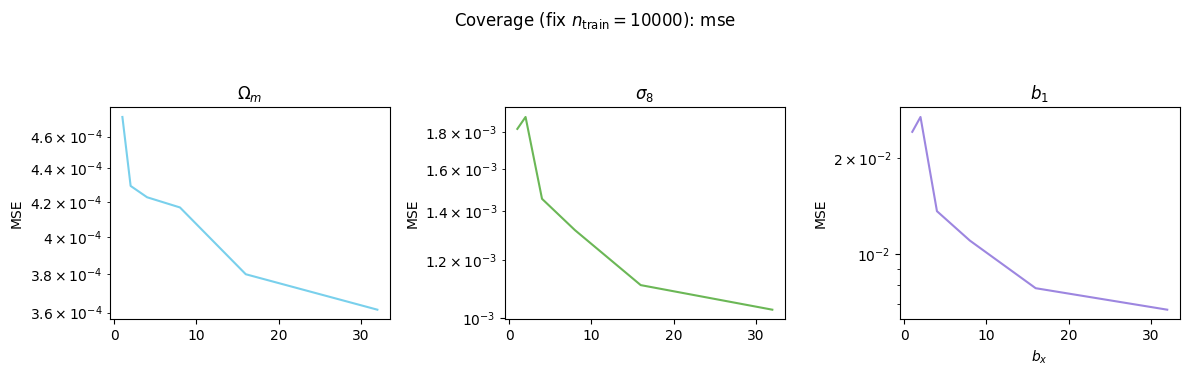

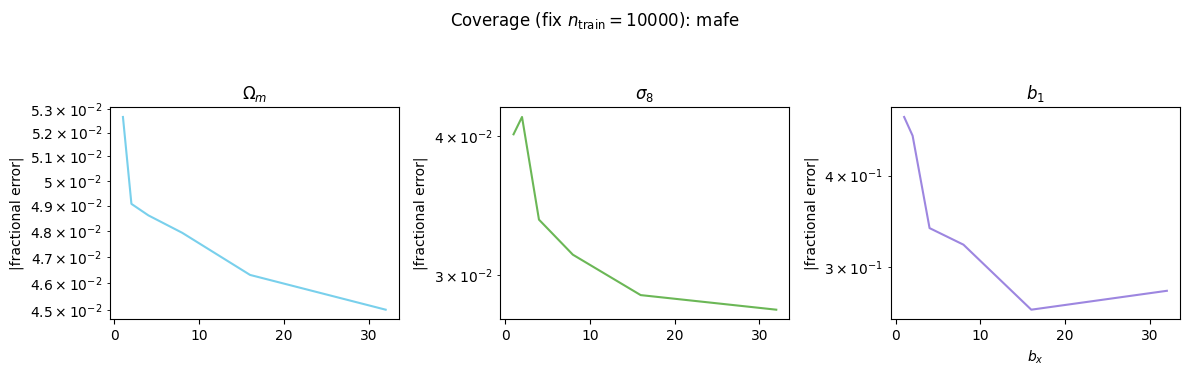

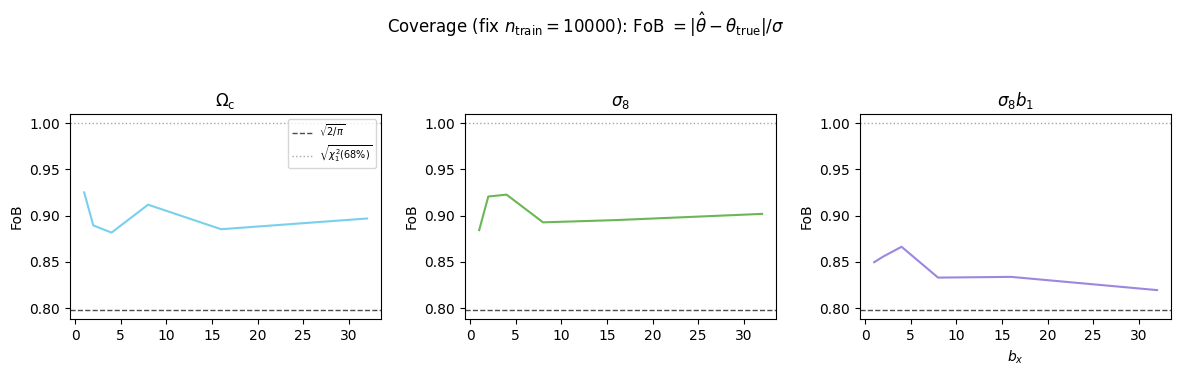

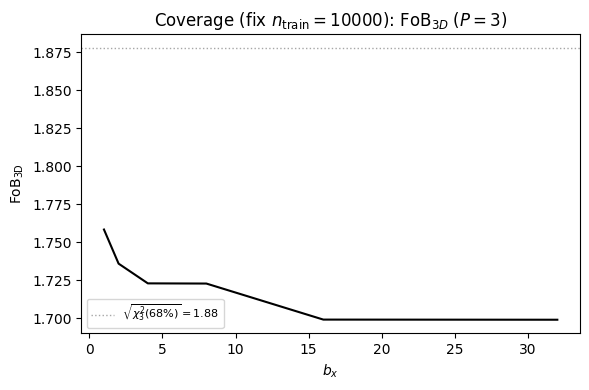

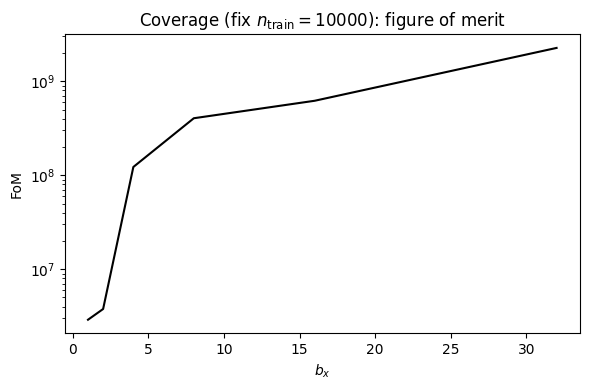

In [6]:
df_cov_vary_bx = df_cov_all[df_cov_all["n_train"] == N_TRAIN_MAX].copy()
plot_all_metrics(
    df_cov_vary_bx,
    "bx",
    r"$b_x$",
    rf"Coverage (fix $n_\mathrm{{train}}={N_TRAIN_MAX}$)",
)

### vs total training sims $n_\mathrm{train} \times b_x$ (coverage, colored by $b_x$)


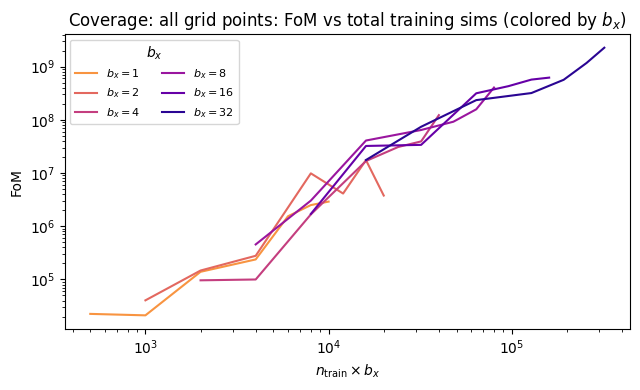

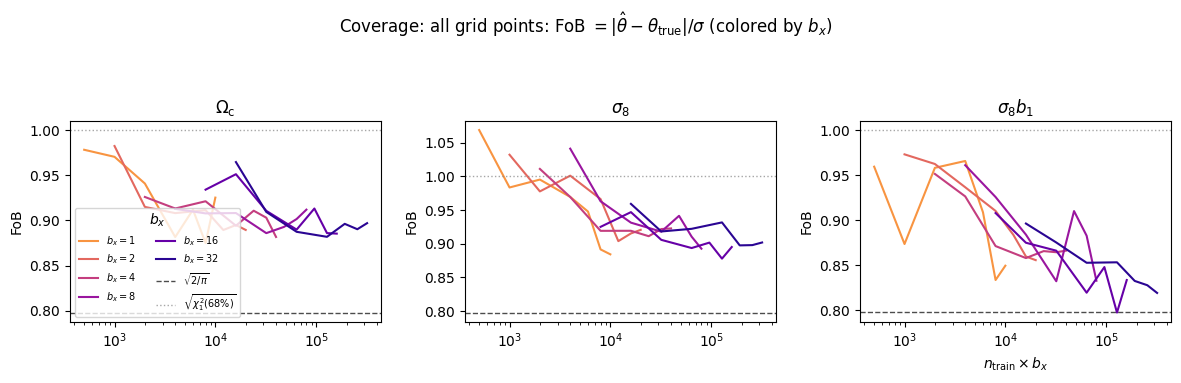

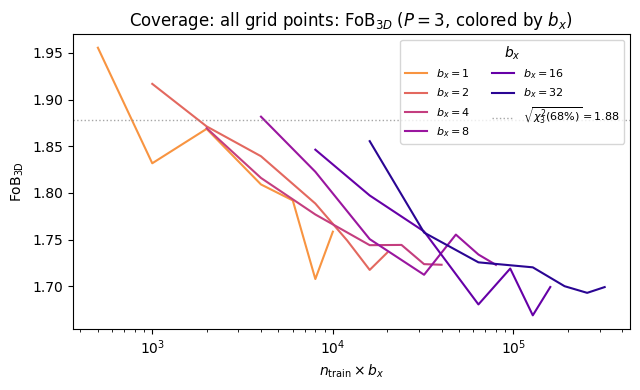

In [7]:
plot_total_sims_colored_by_bx(df_cov_all, "Coverage: all grid points")


### vs total training sims $n_\mathrm{train} \times b_x$ (coverage, colored by $n_\mathrm{train}$)


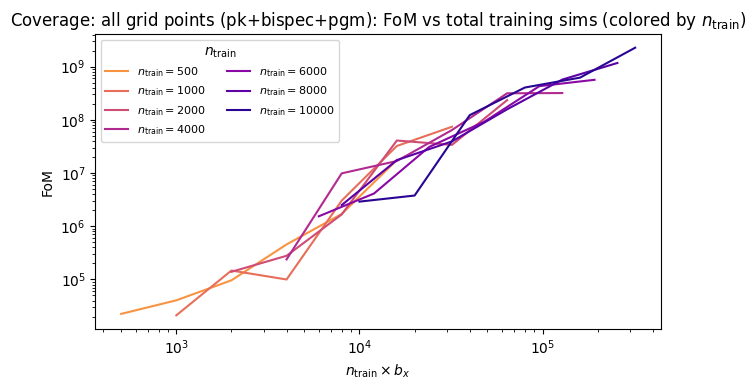

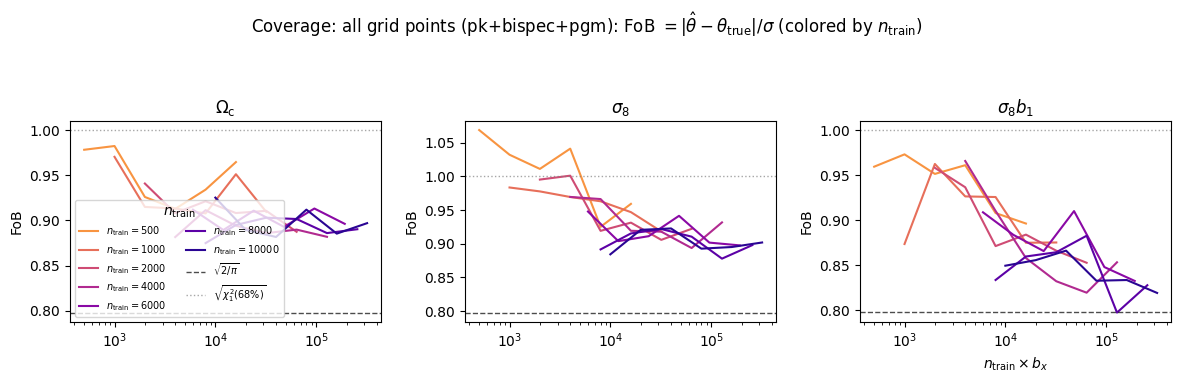

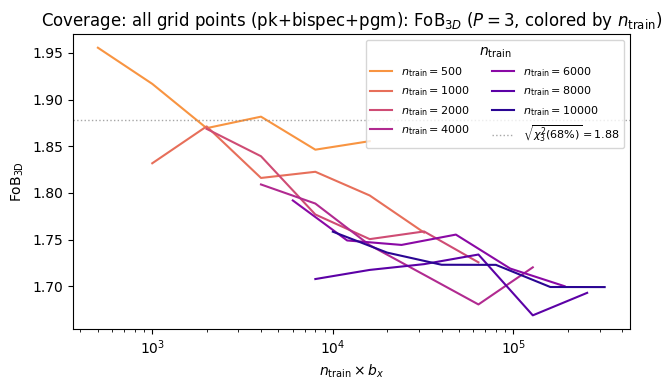

In [8]:
plot_total_sims_colored_by_ntrain(df_cov_all, "Coverage: all grid points (pk+bispec+pgm)")


## Stat combo comparison (fiducial masks, coverage)

Four statistics combinations with fiducial $k_\mathrm{max}$ masks on the coverage LH set.


In [9]:
df_cov_stat_combos = collect_stat_combo_coverage_grids(n_train_arr, bx_arr)
lim3 = fob_chi2_sqrt_limit(3)
print(
    f"Total rows: {len(df_cov_stat_combos)} "
    f"({(df_cov_stat_combos['status'] == 'complete').sum()} complete)"
)
df_cov_stat_combos.groupby("stat_combo").size()


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=1, n_train=10000, n_obs=820 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=2, n_train=10000, n_obs=820 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


...

/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=8, n_train=2000, n_obs=820 / 1000


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


Coverage incomplete (incomplete): bx=32, n_train=500, n_obs=820 / 1000
Coverage summary: 42 loaded, 37 complete / 42 grid points; 0 missing, 5 incomplete
$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$, _kb0.25_kpgm0.25: loaded 42 grid points (37 complete, 5 incomplete / 42 expected)
Total rows: 168 (133 complete)


stat_combo
$P_\mathrm{gg}(k)$                                                              42
$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$, _kb0.25_kpgm0.25    42
$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$, _kb0.25                                  42
$P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$, _kpgm0.25                              42
dtype: int64

### Fix $b_x = 32$, vary $n_\mathrm{train}$


In [10]:
df_cov_sc_vary_ntrain = df_cov_stat_combos[df_cov_stat_combos["bx"] == BX_MAX].copy()


#### Marginal FoM ($1/\sigma_i$), 3-key block


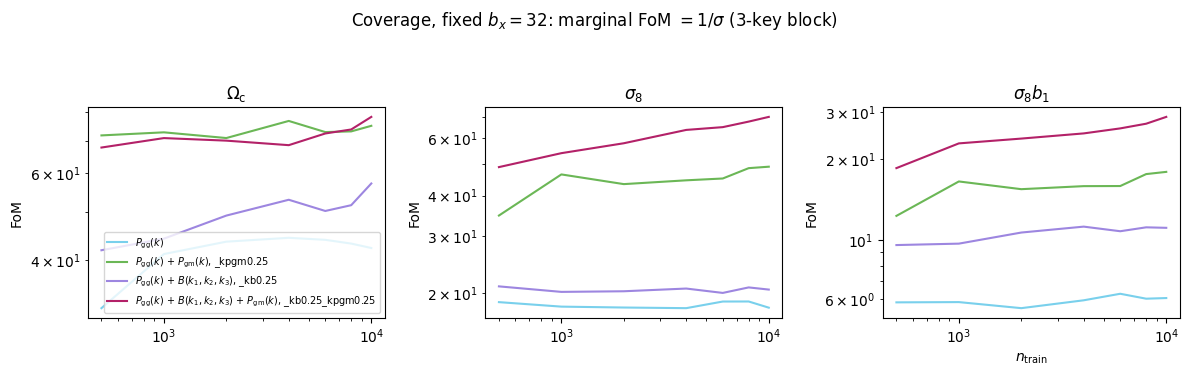

In [11]:
plot_fom_marg_by_stat_combo(
    df_cov_sc_vary_ntrain,
    "n_train",
    r"$n_\mathrm{train}$",
    f"Coverage, fixed $b_x={BX_MAX}$",
    logx=True,
)


#### Marginal FoB ($|\hat{\theta}-\theta_{\mathrm{true}}|/\sigma_i$), 3-key block


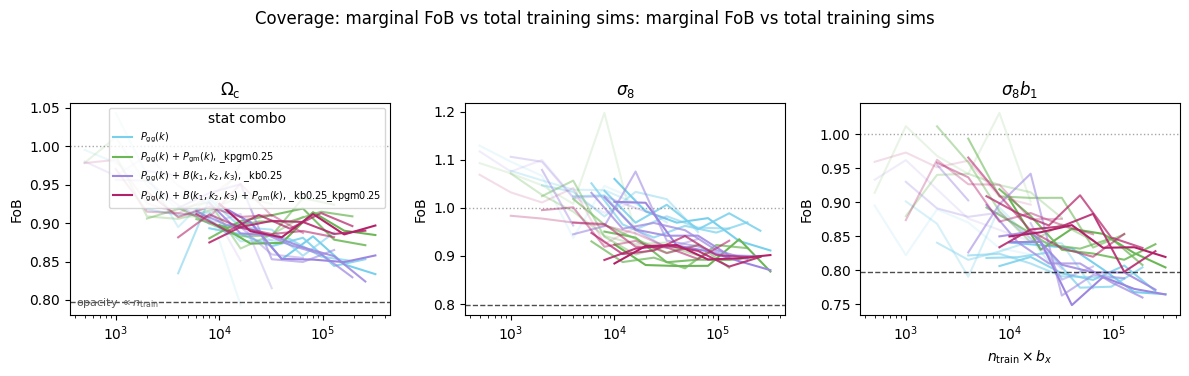

In [12]:
plot_fob_marg_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "Coverage: marginal FoB vs total training sims",
    logx=True,
)


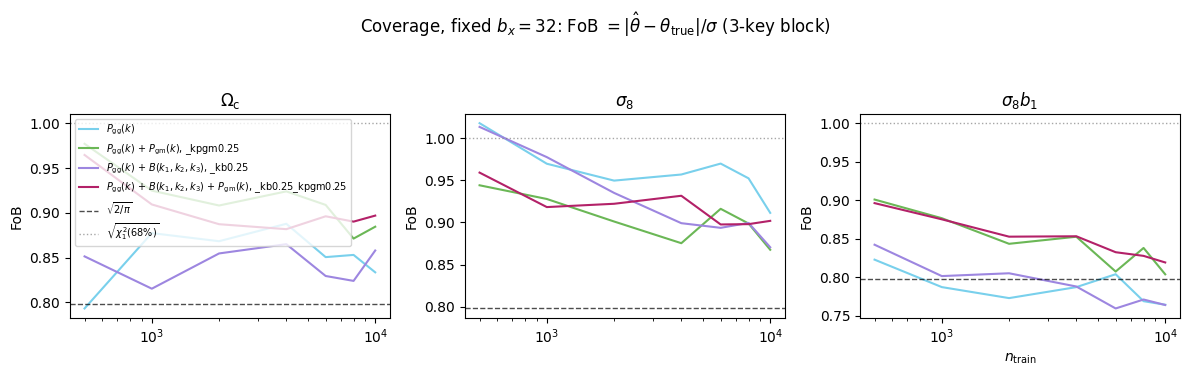

In [13]:
plot_fob_marg_by_stat_combo(
    df_cov_sc_vary_ntrain,
    "n_train",
    r"$n_\mathrm{train}$",
    f"Coverage, fixed $b_x={BX_MAX}$",
    logx=True,
)


#### FoM$_3$, full FoM, FoB$_\mathrm{3D}$


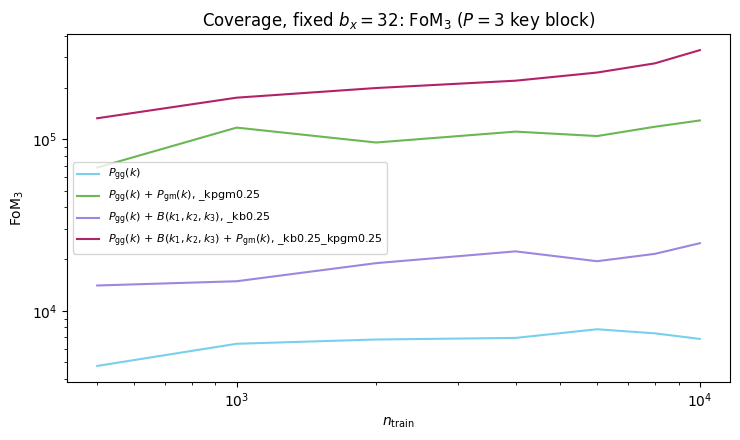

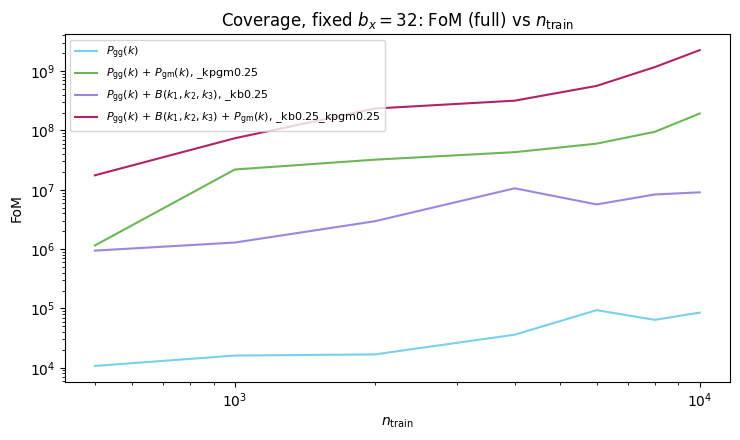

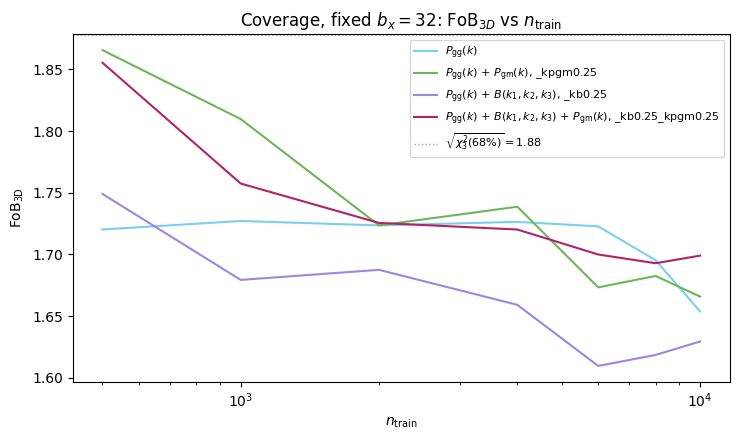

In [14]:
plot_fom_3d_by_stat_combo(
    df_cov_sc_vary_ntrain,
    "n_train",
    r"$n_\mathrm{train}$",
    f"Coverage, fixed $b_x={BX_MAX}$",
    logx=True,
)

plot_metric_by_stat_combo(
    df_cov_sc_vary_ntrain,
    "n_train",
    "fom",
    r"$n_\mathrm{train}$",
    "FoM",
    f"Coverage, fixed $b_x={BX_MAX}$: FoM (full) vs $n_\\mathrm{{train}}$",
    logx=True,
    logy=True,
)

plot_metric_by_stat_combo(
    df_cov_sc_vary_ntrain,
    "n_train",
    "fob3",
    r"$n_\mathrm{train}$",
    r"FoB$_{\mathrm{3D}}$",
    f"Coverage, fixed $b_x={BX_MAX}$: FoB$_{{3D}}$ vs $n_\\mathrm{{train}}$",
    logx=True,
    hline=lim3,
    hline_label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$",
)


### Fix $n_\mathrm{train} = 10000$, vary $b_x$


In [15]:
df_cov_sc_vary_bx = df_cov_stat_combos[df_cov_stat_combos["n_train"] == N_TRAIN_MAX].copy()


#### Marginal FoM ($1/\sigma_i$), 3-key block


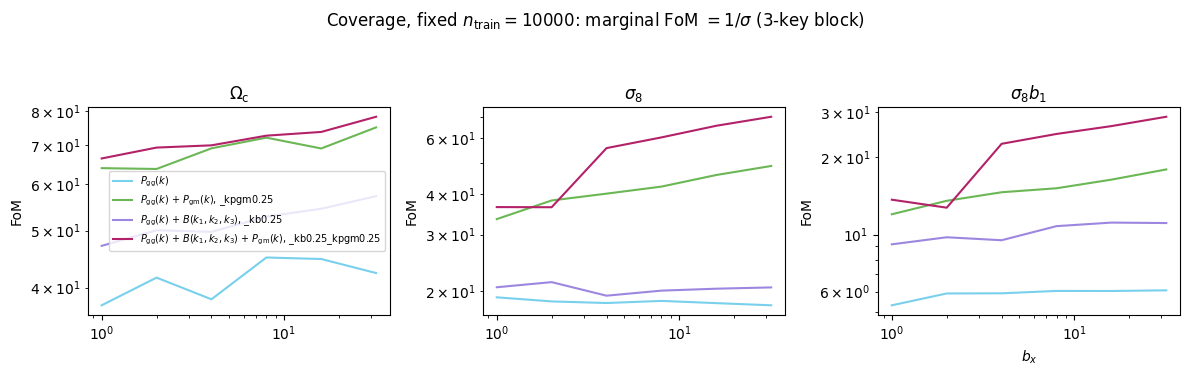

In [16]:
plot_fom_marg_by_stat_combo(
    df_cov_sc_vary_bx,
    "bx",
    r"$b_x$",
    f"Coverage, fixed $n_\\mathrm{{train}}={N_TRAIN_MAX}$",
    logx=True,
)


#### FoM$_3$, full FoM, FoB$_\mathrm{3D}$


#### Marginal FoB ($|\hat{\theta}-\theta_{\mathrm{true}}|/\sigma_i$), 3-key block


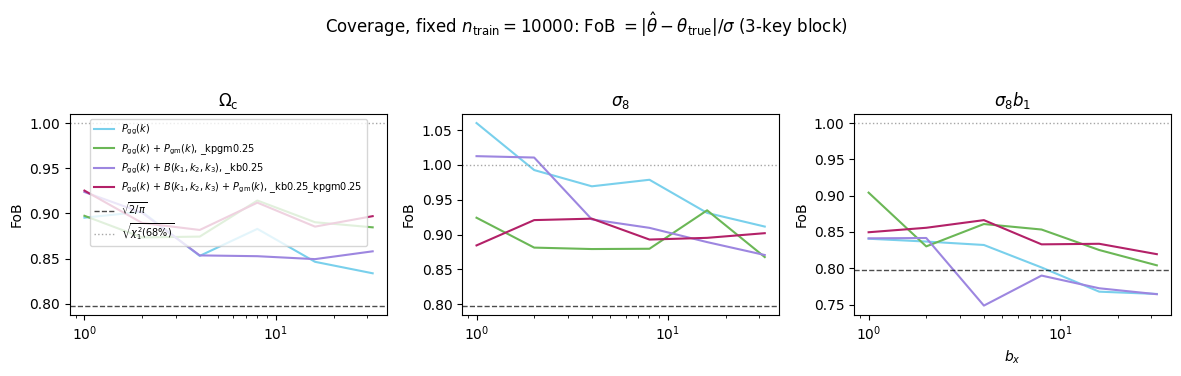

In [17]:
plot_fob_marg_by_stat_combo(
    df_cov_sc_vary_bx,
    "bx",
    r"$b_x$",
    f"Coverage, fixed $n_\\mathrm{{train}}={N_TRAIN_MAX}$",
    logx=True,
)


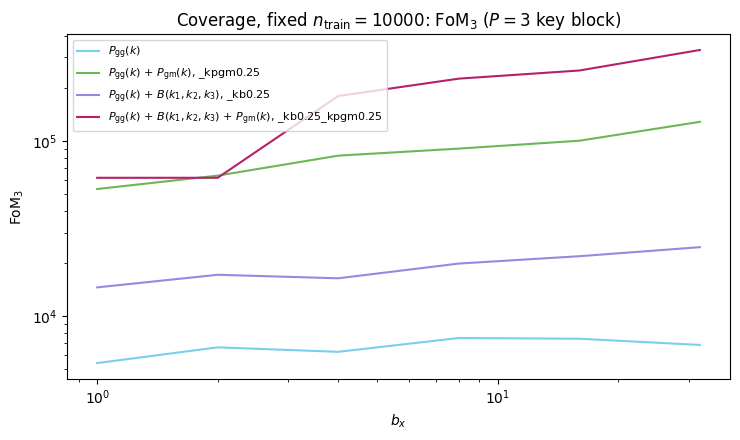

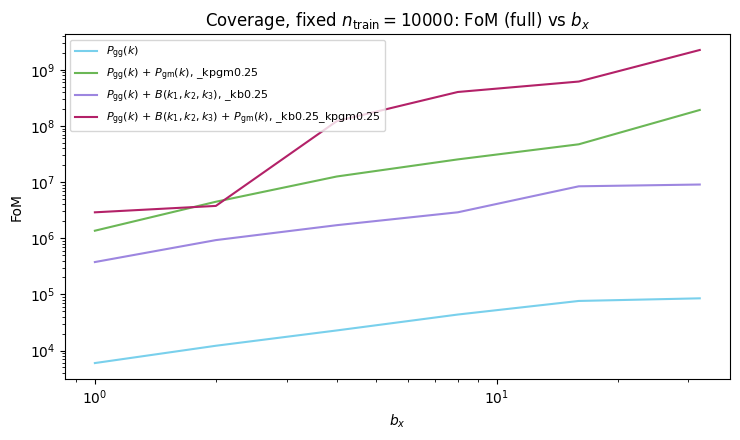

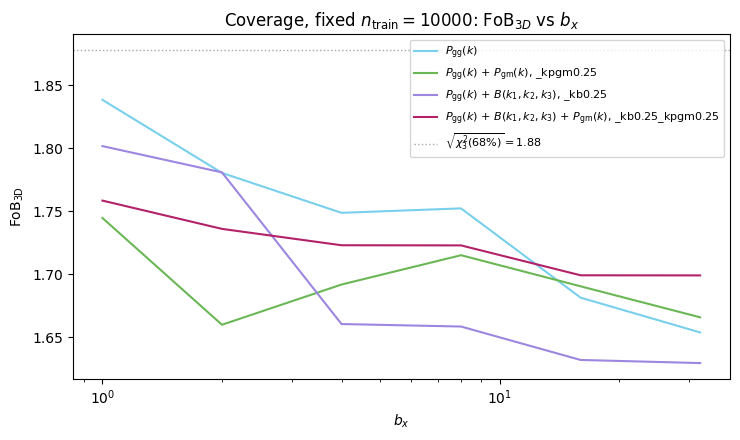

In [18]:
plot_fom_3d_by_stat_combo(
    df_cov_sc_vary_bx,
    "bx",
    r"$b_x$",
    f"Coverage, fixed $n_\\mathrm{{train}}={N_TRAIN_MAX}$",
    logx=True,
)

plot_metric_by_stat_combo(
    df_cov_sc_vary_bx,
    "bx",
    "fom",
    r"$b_x$",
    "FoM",
    f"Coverage, fixed $n_\\mathrm{{train}}={N_TRAIN_MAX}$: FoM (full) vs $b_x$",
    logx=True,
    logy=True,
)

plot_metric_by_stat_combo(
    df_cov_sc_vary_bx,
    "bx",
    "fob3",
    r"$b_x$",
    r"FoB$_{\mathrm{3D}}$",
    f"Coverage, fixed $n_\\mathrm{{train}}={N_TRAIN_MAX}$: FoB$_{{3D}}$ vs $b_x$",
    logx=True,
    hline=lim3,
    hline_label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$",
)


### vs $n_\mathrm{train} \times b_x$ (opacity $\propto n_\mathrm{train}$)


#### Marginal FoM ($1/\sigma_i$), 3-key block


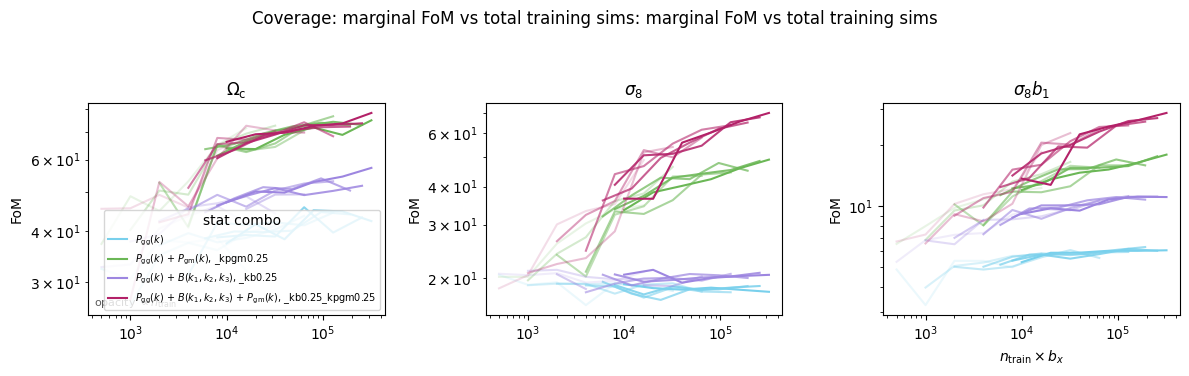

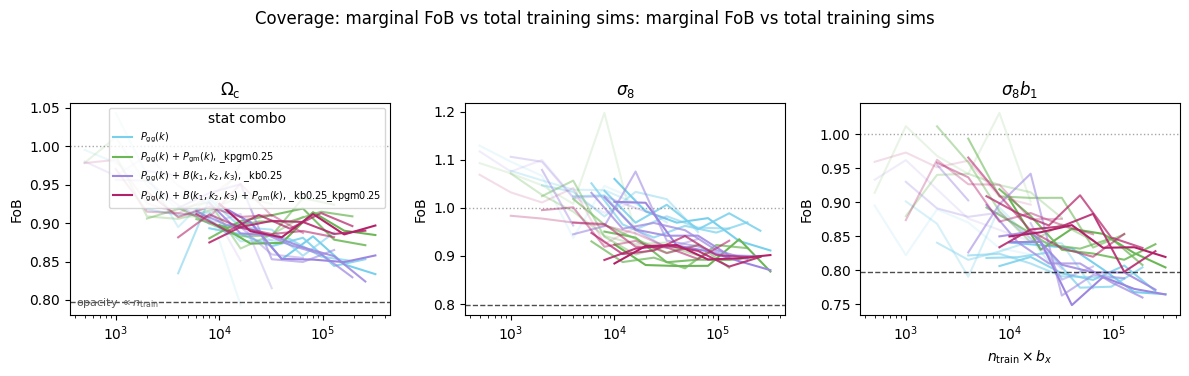

In [19]:
plot_fom_marg_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "Coverage: marginal FoM vs total training sims",
    logx=True,
)

plot_fob_marg_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "Coverage: marginal FoB vs total training sims",
    logx=True,
)


#### Marginal FoB ($|\hat{\theta}-\theta_{\mathrm{true}}|/\sigma_i$), 3-key block


#### FoM$_3$, full FoM, FoB$_\mathrm{3D}$


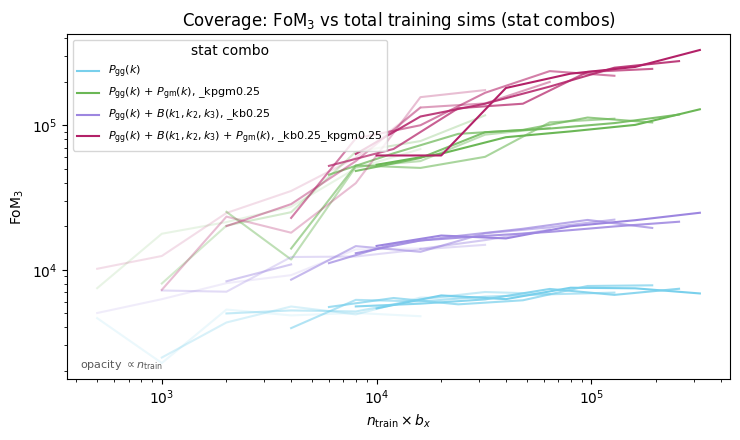

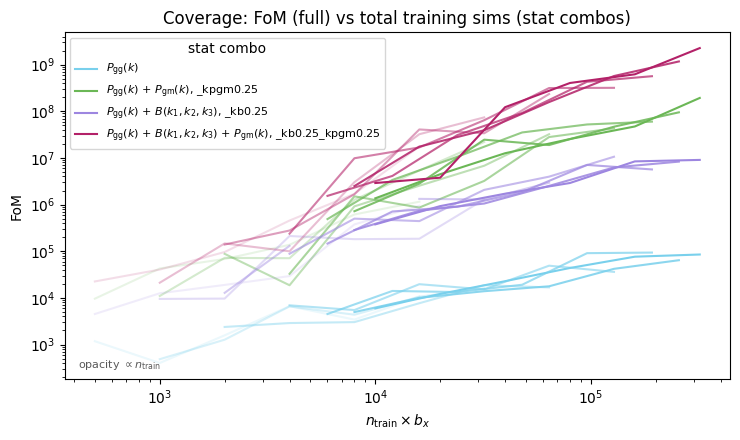

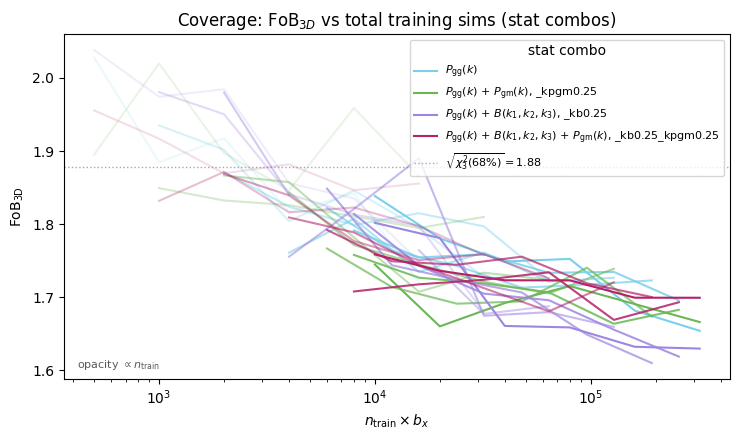

In [20]:
plot_metric_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "fom_3d",
    r"FoM$_{\mathrm{3}}$",
    "Coverage: FoM$_{3}$ vs total training sims (stat combos)",
    logx=True,
    logy=True,
)

plot_metric_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "fom",
    "FoM",
    "Coverage: FoM (full) vs total training sims (stat combos)",
    logx=True,
    logy=True,
)

plot_metric_by_stat_combo_nsims_alpha(
    df_cov_stat_combos,
    "fob3",
    r"FoB$_{\mathrm{3D}}$",
    "Coverage: FoB$_{3D}$ vs total training sims (stat combos)",
    logx=True,
    hline=lim3,
    hline_label=rf"$\sqrt{{\chi^2_{{3}}(68\%)}}={lim3:.2f}$",
)
